SIT 374 - USIA

EDA - Exploratory Data Analysis

Loading Datasets

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import geopandas as gpd
import pandas as pd

STREETS_PATH = "/content/drive/MyDrive/streets_spatial.gpkg"

POPUP_PATH = "/content/drive/MyDrive/popup_bike_lanes.geojson"

popup = gpd.read_file(POPUP_PATH)
streets = gpd.read_file(STREETS_PATH)

print(popup.columns.tolist())
print(popup.head(1).T)


['fid', 'roadnm', 'side', 'trialdate', 'postdate', 'lga', 'trialinfra', 'postinfra', 'geometry']
                                                            0
fid                                                         2
roadnm                                         Charles Street
side                                                    North
trialdate                                              Jul-22
postdate                                                 None
lga                                               Maribyrnong
trialinfra                                       Painted lane
postinfra                                                None
geometry    MULTILINESTRING ((144.89243393741438 -37.80671...


Parsing dates and checking the full range first.

Before filtering to COVID period, lets see what data range this dataset spans.

In [3]:
popup['trialdate'] = pd.to_datetime(popup['trialdate'],format = '%b-%y',errors='coerce')
popup['postdate'] = pd.to_datetime(popup['postdate'],format = '%b-%y',errors='coerce')

print("Trial date range : ",popup['trialdate'].min(),"to",popup['trialdate'].max())
print("Missing Trial dates : ",popup['trialdate'].isna().sum())


Trial date range :  2021-04-01 00:00:00 to 2022-07-01 00:00:00
Missing Trial dates :  5


Trial Date Range Findings

The pop-up bike lane dataset's 'trialdate' field spans **April 2021 to July 2022**, with 5 records missing a trial date. This is a narrower window than Melbourne's full COVID lockdown period (March 2020 - October 2021).

The popup lanes in this dataset were mostly trialled after majority of lockdowns had already occured and range extends 9 months beyond when lockdowns ended entirely.

#### Joining Pop-up Lanes to Street Spatial Data

Before building the treatment/control comparison, we join the pop-up bike lane dataset to `street_spatial.gpkg` using road name (`roadnm`) as the key. This brings each matched treatment street's `trialdate` into the main spatial dataset, which will act as the "before/after" split point for that street.

We also keep the COVID-period filter as a flag rather than dropping rows — this preserves the full dataset (April 2021–July 2022) while still letting us separately identify which trials fall within the COVID lockdown tail-end (up to October 2021), in case that distinction becomes useful later in the analysis or write-up.

In [4]:
# Normalize street names on both sides: uppercase + strip whitespace
streets['street_name_clean'] = streets['street_name'].str.upper().str.strip()
popup['roadnm_clean'] = popup['roadnm'].str.upper().str.strip()

print(streets['street_name_clean'].head())
print(popup['roadnm_clean'].head())
# create the flag first
covid_end = pd.Timestamp("2021-10-31")
popup['is_covid_period'] = popup['trialdate'] <= covid_end
# then include it in the merge column list
streets_popup = streets.merge(
    popup[['roadnm_clean', 'side', 'trialdate', 'postdate', 'trialinfra', 'postinfra', 'is_covid_period']],
    left_on='street_name_clean',
    right_on='roadnm_clean',
    how='left'
)

print(f"Streets matched to a pop-up trial: {streets_popup['trialdate'].notna().sum()}")
streets_popup[streets_popup['trialdate'].notna()].head()

0         KEILOR ROAD
1         KEILOR ROAD
2     VICTORIA AVENUE
3         MALING ROAD
4    STEPHENSONS ROAD
Name: street_name_clean, dtype: object
0    CHARLES STREET
1     ALBERT STREET
2     ALBERT STREET
3    MITFORD STREET
4      BEACH AVENUE
Name: roadnm_clean, dtype: object
Streets matched to a pop-up trial: 119


,street_name,street_segment_id,suburb,postcode,lga,treatment_or_control,intervention_type,cbd,metro,regional,geometry,street_name_clean,roadnm_clean,side,trialdate,postdate,trialinfra,postinfra,is_covid_period
154,HOPKINS STREET,9209.0,Footscray,3011,Maribyrnong (C),control,control,0.0,1.0,0.0,"LINESTRING (2491157.508 2411251.309, 2491161.1...",HOPKINS STREET,HOPKINS STREET,South,2022-07-01,NaT,Shared path,None,False
166,VICTORIA STREET,10219.0,Seddon,3011,Maribyrnong (C),control,control,0.0,1.0,0.0,"LINESTRING (2490471.871 2410477.539, 2490476.9...",VICTORIA STREET,VICTORIA STREET,East,2022-07-01,NaT,Painted lane,None,False
167,VICTORIA STREET,10219.0,Seddon,3011,Maribyrnong (C),control,control,0.0,1.0,0.0,"LINESTRING (2490471.871 2410477.539, 2490476.9...",VICTORIA STREET,VICTORIA STREET,West,2022-07-01,NaT,Painted lane,None,False
168,VICTORIA STREET,10221.0,Seddon,3011,Maribyrnong (C),control,control,0.0,1.0,0.0,"LINESTRING (2490496.798 2410657.273, 2490501.7...",VICTORIA STREET,VICTORIA STREET,East,2022-07-01,NaT,Painted lane,None,False
169,VICTORIA STREET,10221.0,Seddon,3011,Maribyrnong (C),control,control,0.0,1.0,0.0,"LINESTRING (2490496.798 2410657.273, 2490501.7...",VICTORIA STREET,VICTORIA STREET,West,2022-07-01,NaT,Painted lane,None,False


In [5]:
streets_set = set(streets['street_name_clean'].dropna().unique())
popup_set = set(popup['roadnm_clean'].dropna().unique())

overlap = streets_set & popup_set
print(f"Streets in street_spatial.gpkg: {len(streets_set)}")
print(f"Roads in pop-up dataset: {len(popup_set)}")
print(f"Exact name overlap: {len(overlap)}")
print(overlap)

Streets in street_spatial.gpkg: 137
Roads in pop-up dataset: 109
Exact name overlap: 11
{'WALKER STREET', 'NAPIER STREET', 'PARK STREET', 'HOPKINS STREET', 'HEIDELBERG ROAD', 'ALBERT STREET', 'STATION STREET', 'WILLIAM STREET', 'VICTORIA STREET', 'WELLINGTON STREET', 'ACLAND STREET'}


#### Pop-up Bike Lane to Street Spatial Join — Results

Joining the pop-up bike lanes dataset to `street_spatial.gpkg` on road name (after normalising case and whitespace) returned only **11 exact street name matches** out of 137 study streets and 109 pop-up roads. This is in line with the ~7/96 match rate the team found in earlier manual review, and confirms this is a genuine data coverage gap rather than a join/formatting error — the majority of pop-up bike lanes from Transport Victoria's dataset simply aren't on the streets included in this study.

Of the 4 trials flagged as falling within the COVID lockdown period (up to Oct 2021), it's still to be confirmed how many of those fall within this 11-street matched set.

**Implication:** These 11 streets are currently the only ones in the dataset with a confirmed intervention date. The remaining streets still lack installation dates entirely — this is the same gap raised with the PO in the Week 4 meeting and remains unresolved. Given the small sample size, this match is treated as a proof-of-concept for the before/after methodology rather than a basis for broader conclusions at this stage.


In [6]:
matched_rows = streets_popup['trialdate'].notna().sum()
matched_unique_names = streets_popup.loc[streets_popup['trialdate'].notna(), 'street_name_clean'].nunique()
matched_unique_segments = streets_popup.loc[streets_popup['trialdate'].notna(), 'street_segment_id'].nunique()

print(f"Matched rows: {matched_rows}")
print(f"Unique street names matched: {matched_unique_names}")
print(f"Unique street segments matched: {matched_unique_segments}")


Matched rows: 119
Unique street names matched: 11
Unique street segments matched: 28


## Phase 1 — Initial Approach: Pop-up Bike Lanes Join (Superseded)

The cells above document our first attempt at sourcing intervention dates, using Transport
Victoria's Pop-up Bike Lanes dataset joined on street name. This returned only **11 exact
matches** out of 137 study streets, several of which were generic names (e.g. "William Street")
at real risk of false-positive matches across suburbs.

This finding was reported to the PO, who subsequently provided `sites_db.csv` and
`street_segment_qtr_attributes.csv` — richer, ID-keyed datasets that resolve this gap.
**Phase 2 below supersedes this approach** and is what the rest of the analysis builds on.

## Phase 2 — Current Approach: sites_db.csv & street_segment_qtr_attributes.csv

Using `StreetSegmentID`-based joins instead of name-based matching, resolving both the
match-rate and false-positive risk identified in Phase 1.

#### Loading the New PO Datasets

`sites_db.csv` is keyed directly on `StreetSegmentID`, matching our existing `street_segment_id`
field — a much more reliable join than the name-based pop-up lane match used in Phase 1.
`street_segment_qtr_attributes.csv` provides a genuine quarterly time series per segment,
going back to the late 1990s.

Both files use a non-UTF-8 encoding (likely saved from Excel), so we load them with
`encoding='latin1'` to avoid decode errors.

In [7]:
sites_db = pd.read_csv("/content/drive/MyDrive/sites_db.csv", encoding='latin1')
qtr_attrs = pd.read_csv("/content/drive/MyDrive/street_segment_qtr_attributes.csv", encoding='latin1')
print(sites_db.shape, qtr_attrs.shape)
print(sites_db['SiteType'].value_counts())
print(sites_db['InterventionType'].value_counts())

(637, 35) (30783, 15)
SiteType
Intervention    442
Control         195
Name: count, dtype: int64
InterventionType
ProtectedBikeLane        416
Control                  195
Regional Reallocation     12
Pedestrianisation          9
Name: count, dtype: int64


#### Parsing Intervention Dates

`DisruptionStartDate` / `DisruptionEndDate` are stored as `YYYYMMDD` floats (e.g. `20240623.0`)
rather than proper dates, so we parse them explicitly. A missing `DisruptionEndDate` (rather
than any specific date value) is used as the signal for an ongoing disruption, since no single
end-date value dominates the data strongly enough to act as a reliable "still ongoing" sentinel.

In [8]:
def parse_yyyymmdd(series):
    return pd.to_datetime(series.dropna().astype('Int64').astype(str), format='%Y%m%d', errors='coerce')
sites_db['DisruptionStartDate_parsed'] = parse_yyyymmdd(sites_db['DisruptionStartDate'])
sites_db['DisruptionEndDate_parsed'] = parse_yyyymmdd(sites_db['DisruptionEndDate'])
# A missing end date is a more reliable "still ongoing" signal than any single date value
sites_db['disruption_still_ongoing'] = sites_db['DisruptionEndDate_parsed'].isna() & sites_db['DisruptionStartDate_parsed'].notna()
print(f"Disruptions with a start date but no end date (likely still ongoing): {sites_db['disruption_still_ongoing'].sum()}")
print(f"Disruptions with both start and end dates: {(sites_db['DisruptionStartDate_parsed'].notna() & sites_db['DisruptionEndDate_parsed'].notna()).sum()}")
print(f"Rows with no start date at all: {sites_db['DisruptionStartDate_parsed'].isna().sum()}")
print(sites_db['DisruptionEndDate_parsed'].describe())

Disruptions with a start date but no end date (likely still ongoing): 0
Disruptions with both start and end dates: 235
Rows with no start date at all: 402
count                              289
mean     2019-05-10 15:41:43.806228480
min                2009-10-12 00:00:00
25%                2016-09-17 00:00:00
50%                2020-09-07 00:00:00
75%                2022-12-03 00:00:00
max                2025-12-12 00:00:00
Name: DisruptionEndDate_parsed, dtype: object


In [9]:
streets_sites = streets.merge( sites_db[['StreetSegmentID', 'SiteType', 'InterventionType', 'DisruptionStartDate_parsed', 'DisruptionEndDate_parsed', 'disruption_still_ongoing']],left_on='street_segment_id', right_on='StreetSegmentID',how='left')
matched_treatment_v2 = streets_sites[(streets_sites['treatment_or_control'] == 'treatment') & (streets_sites['DisruptionStartDate_parsed'].notna())].copy()
print(f"Treatment segments with a confirmed intervention date: {matched_treatment_v2['street_segment_id'].nunique()} (was 11 via pop-up join)")

Treatment segments with a confirmed intervention date: 77 (was 11 via pop-up join)


Investigating the 19 Unmatched Treatment Segments

77 of 96 treatment segments now have a confirmed intervention date via sites_db.csv. Before proceeding to build the event-level dataset from those 77, we investigate the remaining 19 — specifically whether any can be recovered from the Phase 1 pop-up bike lanes dataset, and whether the gap is concentrated in particular LGAs.

In [10]:
matched_ids = set(matched_treatment_v2['street_segment_id'].unique())
all_treatment = streets[streets['treatment_or_control'] == 'treatment']
unmatched = all_treatment[~all_treatment['street_segment_id'].isin(matched_ids)]
print(f"Unmatched treatment segments: {len(unmatched)}")
print(unmatched[['street_segment_id', 'street_name', 'suburb', 'lga']])

Unmatched treatment segments: 19
     street_segment_id             street_name            suburb  \
208              859.0        RATHDOWNE STREET           Carlton   
209              990.0               CITY ROAD         Southbank   
210             1446.0             PARK STREET         Melbourne   
218             1903.0            STURT STREET         Southbank   
219             1970.0            ANZAC AVENUE         Melbourne   
221             3100.0  GOVERNMENT HOUSE DRIVE         Melbourne   
223             3125.0         KAVANAGH STREET         Southbank   
225             3504.0             HIGH STREET           Wodonga   
240             5634.0     SOUTHBANK BOULEVARD         Southbank   
241             5635.0     SOUTHBANK BOULEVARD         Southbank   
249             6237.0                 BAIR ST         Leongatha   
283            10916.0       LINLITHGOW AVENUE         Melbourne   
295             1587.0            ARMSTRONG ST  Ballarat Central   
297            

Checking for Recoverable Dates via the Phase 1 Pop-up Dataset

Before treating these 19 as a confirmed gap, we check whether any appear in the pop-up bike lanes dataset under the same street name — the Phase 1 join failed at the full-dataset level, but a match might still exist for one of these specific streets.

In [11]:
unmatched_names = unmatched['street_name_clean'].unique()
recoverable = popup[popup['roadnm_clean'].isin(unmatched_names)]
print(recoverable[['roadnm_clean', 'trialdate']])

    roadnm_clean  trialdate
127  PARK STREET 2022-07-01
277  PARK STREET 2022-07-01


Result: False Positive, Not a Recovery

The only name match found was "Park Street" — but cross-checking the full record shows this pop-up trial is in Moonee Valley, not Melbourne. Our unmatched segment 1446 is Park Street, suburb Melbourne, LGA Melbourne (C) — a different street that happens to share a name. This is the exact false-positive risk flagged in Phase 1 (generic street names like "William Street"). We reject this match and treat all 19 segments as having no recoverable date from either dataset.

In [12]:
print(popup.loc[[127, 277]].T)  # confirms LGA mismatch

                                                               127  \
fid                                                            131   
roadnm                                                 Park Street   
side                                                         North   
trialdate                                      2022-07-01 00:00:00   
postdate                                                       NaT   
lga                                                  Moonee Valley   
trialinfra                                           Shared street   
postinfra                                                     None   
geometry         MULTILINESTRING ((144.91096115714097 -37.76102...   
roadnm_clean                                           PARK STREET   
is_covid_period                                              False   

                                                               277  
fid                                                            287  
roadnm               

Known Gap: Three LGAs Have Zero Dated Treatment Segments

Breaking the 19 unmatched segments down by LGA reveals this isn't just scattered noise — three entire target LGAs have no confirmed intervention date for any treatment segment:

Warrnambool (C) — 4 segments (all Liebig Street)
Ballarat (C) — 3 segments (Armstrong St, Little Bridge St, Main Rd)
South Gippsland (S) — 1 segment (Bair St, Leongatha)

This means no before/after intervention timeline can currently be built for these three regions. Melbourne (C) also has 10 unmatched segments, but retains strong coverage elsewhere, so it is not a completeness failure in the same way.

We do not attempt to impute these dates — a fabricated date would silently corrupt any before/after comparison for these streets.

In [13]:
print("Unmatched segments by LGA:")
print(unmatched['lga'].value_counts())
matched_lgas = set(all_treatment[all_treatment['street_segment_id'].isin(matched_ids)]['lga'].unique())
all_lgas = set(all_treatment['lga'].unique())
print("\nLGAs with ZERO dated segments:", all_lgas - matched_lgas)

Unmatched segments by LGA:
lga
Melbourne (C)          10
Warrnambool (C)         4
Ballarat (C)            3
South Gippsland (S)     1
Wodonga (C)             1
Name: count, dtype: int64

LGAs with ZERO dated segments: {'Ballarat (C)', 'Warrnambool (C)', 'South Gippsland (S)'}


#### Infrastructure Map: Treatment Segments Across Target LGAs

Our task requires mapping infrastructure, not just listing it in tables. Building on the
date-confirmation status established above (`matched_ids`, the 19-segment gap, and the
3-LGA completeness finding), we plot every treatment segment across Victoria — coloured by
intervention type, with a red outline marking segments still missing a confirmed date. A
statewide panel shows the full geographic spread, including the three LGAs with zero date
coverage; a zoomed panel gives a legible view of the dense inner-Melbourne cluster, our
priority sites.

In [14]:
# Region label, used to split the statewide view from the zoomed inner-Melbourne view
def region_label(row):
    if row['cbd'] == 1:
        return 'CBD'
    elif row['metro'] == 1:
        return 'Metro'
    elif row['regional'] == 1:
        return 'Regional'
    return 'Unknown'

streets['region'] = streets.apply(region_label, axis=1)

# Date coverage status per segment, reusing matched_ids from the unmatched-segment check above
streets['date_status'] = 'Control'
streets.loc[streets['treatment_or_control'] == 'treatment', 'date_status'] = 'No confirmed date'
streets.loc[streets['street_segment_id'].isin(matched_ids), 'date_status'] = 'Date confirmed'

print(streets['date_status'].value_counts())

date_status
Control              219
Date confirmed        77
No confirmed date     19
Name: count, dtype: int64


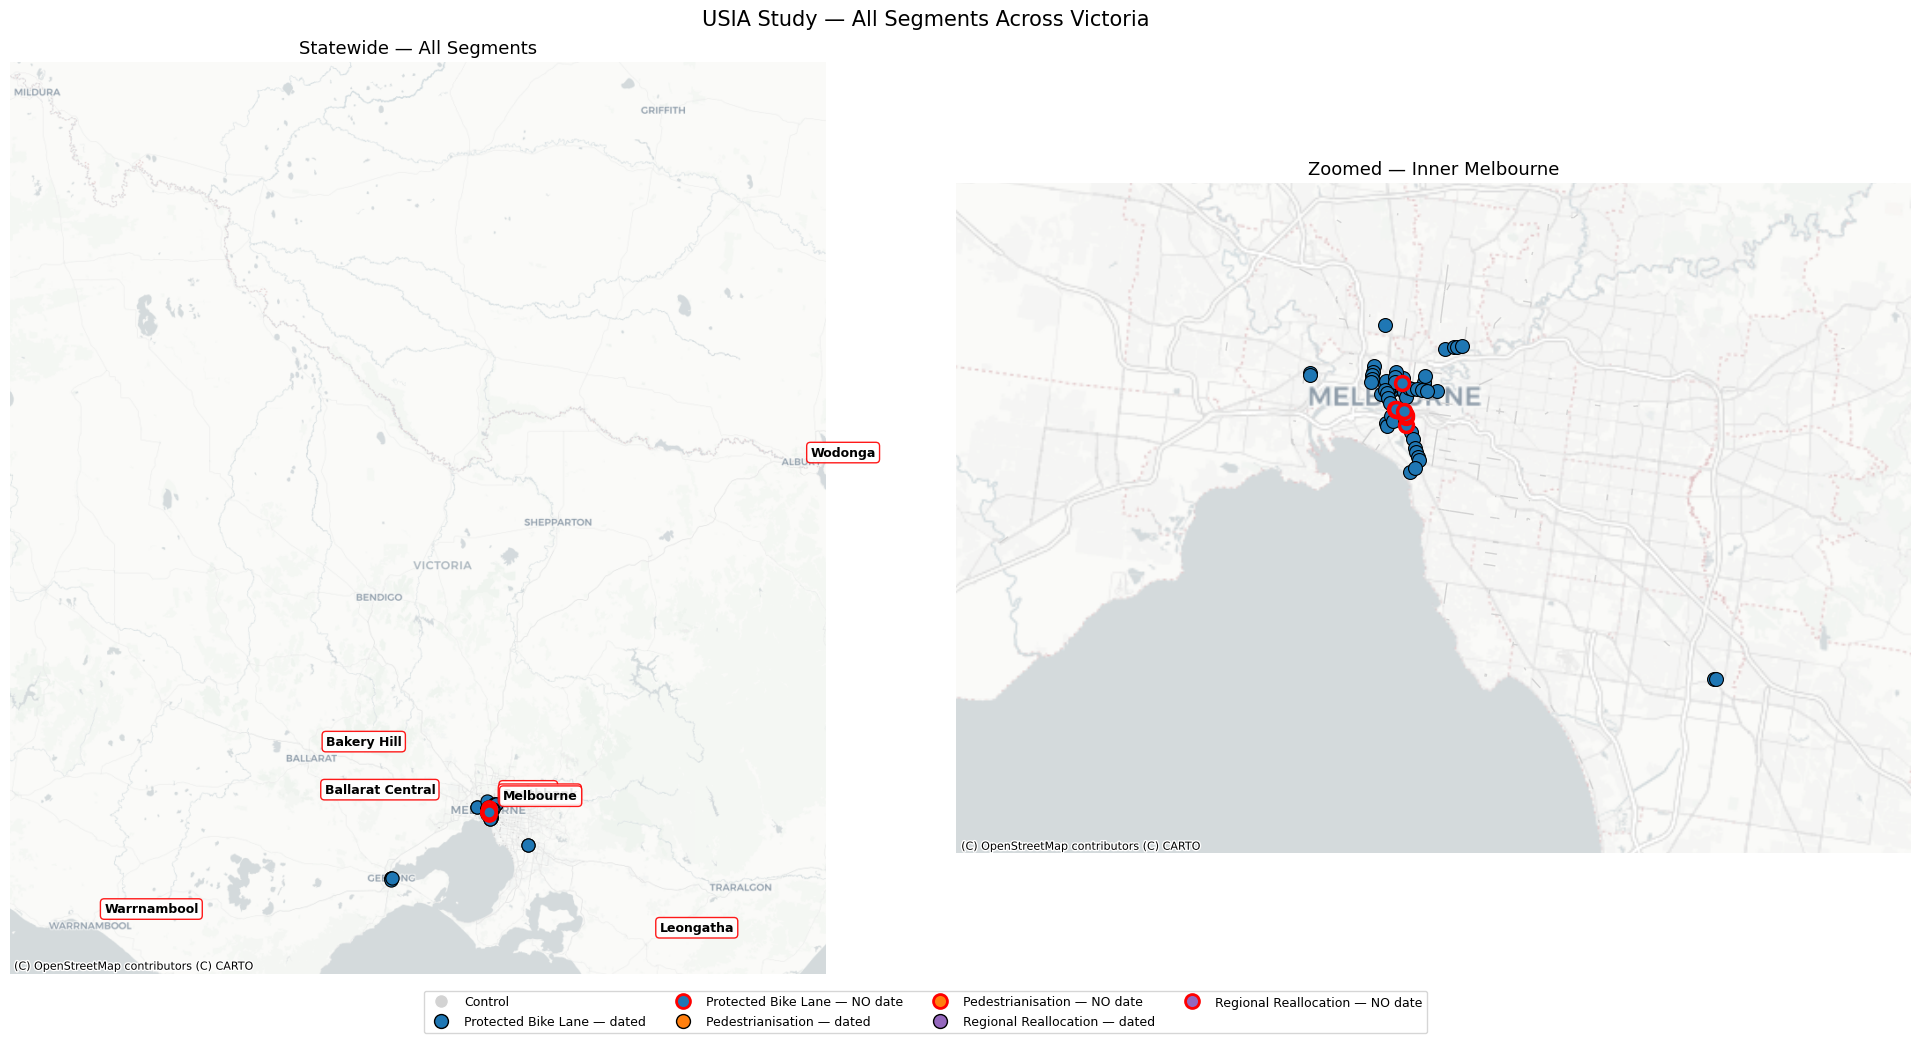

In [15]:
import contextily as cx
import matplotlib.pyplot as plt

# --- Reproject to Web Mercator for basemap compatibility ---
streets_3857 = streets.to_crs(epsg=3857)

type_colors = {
    'protected bike lane': 'tab:blue',
    'pedestrianisation': 'tab:orange',
    'regional reallocation': 'tab:purple',
}

# Manual offsets for labels that sit close together and would otherwise overlap
label_offsets = {
    'Bakery Hill': (10, 10),
    'Ballarat Central': (10, -25),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

for ax, is_zoomed in [(ax1, False), (ax2, True)]:
    data = streets_3857[streets_3857['region'].isin(['CBD', 'Metro'])] if is_zoomed else streets_3857

    # Controls as background layer
    data[data['treatment_or_control'] == 'control'].plot(
        ax=ax, color='lightgrey', linewidth=1, zorder=1
    )

    # Treatment segments split by type and date status
    for itype, color in type_colors.items():
        confirmed = data[(data['intervention_type'] == itype) & (data['date_status'] == 'Date confirmed')]
        missing = data[(data['intervention_type'] == itype) & (data['date_status'] == 'No confirmed date')]
        if len(confirmed) > 0:
            confirmed.centroid.plot(ax=ax, color=color, markersize=100 if is_zoomed else 90,
                                      edgecolor='black', linewidth=0.8, zorder=3)
        if len(missing) > 0:
            missing.centroid.plot(ax=ax, color=color, markersize=100 if is_zoomed else 90,
                                    edgecolor='red', linewidth=2.5, zorder=3)

    if not is_zoomed:
        # Constrain extent to Victoria's actual bounds so outliers don't blow out the frame
        ax.set_xlim(streets_3857.total_bounds[0] - 20000, streets_3857.total_bounds[2] + 20000)
        ax.set_ylim(streets_3857.total_bounds[1] - 20000, streets_3857.total_bounds[3] + 20000)

        # Label each isolated regional gap once (avoids duplicate labels e.g. 4x Liebig St)
        missing_all = data[data['date_status'] == 'No confirmed date']
        for suburb in missing_all['suburb'].unique():
            row = missing_all[missing_all['suburb'] == suburb].iloc[0]
            pt = row.geometry.centroid
            offset = label_offsets.get(suburb, (10, 10))
            ax.annotate(suburb, (pt.x, pt.y), fontsize=9, fontweight='bold',
                        xytext=offset, textcoords='offset points',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='red', alpha=0.9))
        ax.set_title("Statewide — All Segments", fontsize=13)
    else:
        ax.set_title("Zoomed — Inner Melbourne", fontsize=13)

    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zorder=0)
    ax.set_axis_off()

# Legend — uses Line2D markers (not Patch) since Patch rendered blank swatches earlier
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgrey',
                                markersize=10, label='Control')]
for itype, color in type_colors.items():
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                                        markeredgecolor='black', markersize=10, label=f'{itype.title()} — dated'))
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                                        markeredgecolor='red', markeredgewidth=2, markersize=10,
                                        label=f'{itype.title()} — NO date'))

fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.05))
fig.suptitle("USIA Study — All Segments Across Victoria", fontsize=15)
plt.tight_layout()
plt.show()

#### Map Interpretation

The statewide view confirms the LGA-completeness finding visually: the three LGAs with zero
dated segments (Warrnambool, Ballarat, South Gippsland) sit furthest from the CBD, while
Melbourne's inner/CBD segments — our priority sites — show much stronger date coverage. This
supports treating the regional gap as a data-access issue specific to those sites, not a
systemic problem with `sites_db.csv`. The zoomed panel shows the inner-Melbourne cluster is
dominated by protected bike lane segments, consistent with IV's stated priority.

In [16]:
dupe_check = sites_db[sites_db['StreetSegmentID'].isin(streets[streets['treatment_or_control']=='treatment']['street_segment_id'])]
dupe_counts = dupe_check.groupby('StreetSegmentID').size()
print("Segments with more than one sites_db row:")
print(dupe_counts[dupe_counts > 1])

Segments with more than one sites_db row:
StreetSegmentID
123      3
124      3
125      3
858      2
859      2
        ..
12016    2
12017    2
12018    2
12019    2
12021    3
Length: 78, dtype: int64


#### Handling Multiple Disruption Events per Segment

55 of our 96 matched treatment segments have more than one recorded disruption date. This
likely reflects real-world phased rollouts (e.g. a temporary pop-up trial followed by later
permanent construction), not a data error. Three possible approaches:

1. **Earliest start date** — treats the *first* disruption as the intervention point. Simple,
   but may misrepresent segments where the "real" permanent change came later.
2. **Latest/most recent start date** — treats the *most recent* disruption as the intervention
   point, on the basis that it likely reflects the final/permanent state. Risk: undercounts
   earlier temporary trial effects.
3. **Treat each disruption as a separate before/after event** — most rigorous, but adds
   complexity (a segment could appear multiple times in the analysis with different windows).

We're proceeding with **3rd approach** for Sprint 1, noting this as a limitation
and candidate for refinement in Sprint 2.

#### Building an Event-Level Dataset (Each Disruption as a Separate Before/After Event)

Rather than collapsing each segment to a single intervention date, we treat every recorded disruption as its own before/after event. A single street segment can have multiple events (up to 9 in this dataset) reflecting phased rollouts such as a pop-up trial followed later by permanent construction. Each event gets a unique `event_id` so it can be tracked individually through the rest of the analysis, and is still linked back to its parent `street_segment_id` for reference.

In [17]:
# Build one row per disruption event (not per segment)
events = sites_db[sites_db['DisruptionStartDate_parsed'].notna()].copy()
events = events.sort_values(['StreetSegmentID', 'DisruptionStartDate_parsed'])
events['event_number'] = events.groupby('StreetSegmentID').cumcount() + 1
events['event_id'] = events['StreetSegmentID'].astype(str) + '_evt' + events['event_number'].astype(str)

# Join back to street metadata (name, suburb, lga, treatment_or_control)
treatment_events = events.merge(
    streets[['street_segment_id', 'street_name', 'suburb', 'lga', 'treatment_or_control']],
    left_on='StreetSegmentID', right_on='street_segment_id', how='inner'
)
treatment_events = treatment_events[treatment_events['treatment_or_control'] == 'treatment']

print(f"Total treatment disruption events: {len(treatment_events)}")
print(f"Across {treatment_events['StreetSegmentID'].nunique()} unique treatment segments")
treatment_events[['event_id', 'street_name', 'suburb', 'event_number', 'DisruptionStartDate_parsed', 'DisruptionEndDate_parsed']].head(10)

Total treatment disruption events: 213
Across 77 unique treatment segments


,event_id,street_name,suburb,event_number,DisruptionStartDate_parsed,DisruptionEndDate_parsed
0,123_evt1,GHERINGHAP STREET,Geelong,1,2021-10-06,2021-11-22
1,123_evt2,GHERINGHAP STREET,Geelong,2,2024-02-04,2024-04-23
2,124_evt1,GHERINGHAP STREET,Geelong,1,2021-10-06,2021-11-22
3,124_evt2,GHERINGHAP STREET,Geelong,2,2024-02-04,2024-04-23
4,125_evt1,GHERINGHAP STREET,Geelong,1,2021-10-06,2021-11-22
5,125_evt2,GHERINGHAP STREET,Geelong,2,2024-02-04,2024-04-23
6,858_evt1,RATHDOWNE STREET,Carlton,1,2021-01-22,2021-04-29
7,1659_evt1,ABBOTSFORD STREET,North Melbourne,1,2011-01-29,2011-04-06
8,1659_evt2,ABBOTSFORD STREET,North Melbourne,2,2018-08-23,2018-10-19
9,1659_evt3,ABBOTSFORD STREET,North Melbourne,3,2020-09-07,2020-11-02


#### Pairing Each Event with Comparison Control Streets

Controls are paired the same way as Phase 1, matching on suburb first, falling back to LGA but now at the event level, so every disruption event gets its own set of comparison controls rather than sharing one static set per street.

In [18]:
controls = streets[streets['treatment_or_control'] == 'control']
def find_controls(row, controls_df):
    same_suburb = controls_df[controls_df['suburb'] == row['suburb']]
    if len(same_suburb) > 0:
        return same_suburb['street_segment_id'].tolist(), 'suburb'
    same_lga = controls_df[controls_df['lga'] == row['lga']]
    return same_lga['street_segment_id'].tolist(), 'lga'
control_matches = treatment_events.apply(lambda r: find_controls(r, controls), axis=1)
treatment_events['matched_control_ids'] = control_matches.apply(lambda x: x[0])
treatment_events['control_match_level'] = control_matches.apply(lambda x: x[1])
treatment_events['n_controls'] = treatment_events['matched_control_ids'].apply(len)
print(f"Events with zero matched controls: {(treatment_events['n_controls'] == 0).sum()}")
treatment_events[['event_id', 'street_name', 'suburb', 'n_controls', 'control_match_level']].head(10)

Events with zero matched controls: 4


,event_id,street_name,suburb,n_controls,control_match_level
0,123_evt1,GHERINGHAP STREET,Geelong,5,lga
1,123_evt2,GHERINGHAP STREET,Geelong,5,lga
2,124_evt1,GHERINGHAP STREET,Geelong,5,lga
3,124_evt2,GHERINGHAP STREET,Geelong,5,lga
4,125_evt1,GHERINGHAP STREET,Geelong,5,lga
5,125_evt2,GHERINGHAP STREET,Geelong,5,lga
6,858_evt1,RATHDOWNE STREET,Carlton,32,lga
7,1659_evt1,ABBOTSFORD STREET,North Melbourne,2,suburb
8,1659_evt2,ABBOTSFORD STREET,North Melbourne,2,suburb
9,1659_evt3,ABBOTSFORD STREET,North Melbourne,2,suburb


#### Overlapping Events - Known Limitation

Where a segment has closely-spaced events (such as a pop-up trial in 2021 followed by permanent construction in 2024), the "after" window of one event may overlap with the "before" window of the next. This is a genuine limitation of treating events independently and should be noted in our methodology write-up - we are not attempting to fully resolve it in Sprint 1.

#### Known Gap: No Control Available for High Street, Wodonga

High Street, Wodonga (LGA: Wodonga (C)) has no matching control street at either the suburb or LGA level - our control set doesn't include any Wodonga-area streets. This affects all 4 disruption events recorded for this segment. Options:
1. **Exclude this segment** from the before/after comparison entirely (simplest, and defensible given it's a single segment out of 77).
2. **Widen the fallback matching** - e.g. match on `regional` flag (if the segment is flagged regional, compare against any other regional control, not just same-suburb/LGA).

Given this affects only 1 of 77 segments, we're excluding it for Sprint 1 and noting it as a
scope limitation, rather than adding matching complexity for a single edge case.

In [19]:
# Exclude the one segment with no viable control match
treatment_events_final = treatment_events[treatment_events['n_controls'] > 0].copy()
print(f"Final event count: {len(treatment_events_final)} (was {len(treatment_events)})")
print(f"Final unique segments: {treatment_events_final['StreetSegmentID'].nunique()} (was {treatment_events['StreetSegmentID'].nunique()})")

Final event count: 209 (was 213)
Final unique segments: 76 (was 77)


In [20]:
def parse_fy_quarter(q):
    fy_start_2digit = int(q[:2])
    start_year = 1900 + fy_start_2digit if fy_start_2digit >= 90 else 2000 + fy_start_2digit
    qnum = int(q[-1])
    month_start = {1: 7, 2: 10, 3: 1, 4: 4}[qnum]
    year = start_year if qnum in (1, 2) else start_year + 1
    return pd.Timestamp(year=year, month=month_start, day=1)

qtr_attrs['quarter_start'] = qtr_attrs['QUARTER'].apply(parse_fy_quarter)

# Filter quarterly data to just our treatment segments with valid events
qtr_treatment = qtr_attrs[qtr_attrs['STREET_SEGMENT_ID'].isin(treatment_events_final['StreetSegmentID'])].copy()
print(f"Quarterly rows for our {treatment_events_final['StreetSegmentID'].nunique()} treatment segments: {len(qtr_treatment)}")
print(f"Segments covered: {qtr_treatment['STREET_SEGMENT_ID'].nunique()} / {treatment_events_final['StreetSegmentID'].nunique()}")

Quarterly rows for our 76 treatment segments: 7787
Segments covered: 74 / 76


#### Known Gap: No Quarterly Data for 2 Segments

La Trobe Street (Melbourne) and Southbank Boulevard (Southbank) have confirmed intervention dates but no matching rows in `street_segment_qtr_attributes.csv`. Both are inner-Melbourne, so this doesn't appear to be a regional-coverage pattern, likely just missing from this particular extract. We exclude their events from the quantitative before/after analysis for Sprint 1.

In [21]:
# Exclude events for segments with no quarterly data at all
segments_with_qtr = set(qtr_treatment['STREET_SEGMENT_ID'].unique())
treatment_events_final = treatment_events_final[treatment_events_final['StreetSegmentID'].isin(segments_with_qtr)].copy()
print(f"Final event count: {len(treatment_events_final)}")
print(f"Final unique segments: {treatment_events_final['StreetSegmentID'].nunique()}")

Final event count: 202
Final unique segments: 74


#### Labelling Quarters as Before/After Each Event

For every treatment segment's quarterly records, we label each quarter relative to that specific event's `DisruptionStartDate_parsed` - not a single fixed cutoff, since segments with multiple events need each event's window judged independently.

In [22]:
# For each event, pull the relevant quarterly rows and label before/after
def label_event_quarters(event_row, qtr_df):
    seg_qtrs = qtr_df[qtr_df['STREET_SEGMENT_ID'] == event_row['StreetSegmentID']].copy()
    seg_qtrs['event_id'] = event_row['event_id']
    seg_qtrs['period'] = seg_qtrs['quarter_start'].apply(lambda q: 'before' if q < event_row['DisruptionStartDate_parsed'] else 'after')
    return seg_qtrs
event_quarter_frames = [label_event_quarters(row, qtr_treatment) for _, row in treatment_events_final.iterrows()]
event_quarters = pd.concat(event_quarter_frames, ignore_index=True)
print(f"Total labelled quarter-rows: {len(event_quarters)}")
print(event_quarters['period'].value_counts())
print()
print(event_quarters.groupby('event_id')['period'].value_counts().unstack(fill_value=0).head(10))

Total labelled quarter-rows: 21267
period
before    15557
after      5710
Name: count, dtype: int64

period      after  before
event_id                 
10529_evt1     57      48
10529_evt2     21      84
10530_evt1     57      48
10530_evt2     21      84
10531_evt1     57      48
10531_evt2     21      84
10838_evt1     40      65
10838_evt2     16      89
11077_evt1     34      71
11077_evt2     25      80


Overlapping Windows Confirmed — Segment 10529 Example

Segment 10529 has two disruption events (Aug 2011, Sep 2020). Because each event's before/after
labels span the entire available history rather than a bounded window, the ~9 years between
the two events count as "after" for event 1 and "before" for event 2 simultaneously. This means
before/after rows are not independent across events of the same segment.

Decision for Sprint 1: we bound each event's before/after window to the gap between it and
the adjacent event on the same segment (or the dataset's edge, if there's no adjacent event),
rather than using full history. This prevents double-counting the same quarters across multiple
events.

In [23]:
def label_event_quarters_bounded(event_row, qtr_df, all_events_df):
    seg_qtrs = qtr_df[qtr_df['STREET_SEGMENT_ID'] == event_row['StreetSegmentID']].copy()

    # find this event's neighbours (same segment, sorted by start date)
    seg_events = all_events_df[all_events_df['StreetSegmentID'] == event_row['StreetSegmentID']].sort_values('DisruptionStartDate_parsed')
    seg_events = seg_events.reset_index(drop=True)
    idx = seg_events[seg_events['event_id'] == event_row['event_id']].index[0]

    window_start = seg_events.loc[idx - 1, 'DisruptionStartDate_parsed'] if idx > 0 else pd.Timestamp.min
    window_end = seg_events.loc[idx + 1, 'DisruptionStartDate_parsed'] if idx < len(seg_events) - 1 else pd.Timestamp.max

    seg_qtrs = seg_qtrs[(seg_qtrs['quarter_start'] >= window_start) & (seg_qtrs['quarter_start'] < window_end)]
    seg_qtrs['event_id'] = event_row['event_id']
    seg_qtrs['period'] = seg_qtrs['quarter_start'].apply(
        lambda q: 'before' if q < event_row['DisruptionStartDate_parsed'] else 'after'
    )
    return seg_qtrs

event_quarter_frames = [
    label_event_quarters_bounded(row, qtr_treatment, treatment_events_final)
    for _, row in treatment_events_final.iterrows()
]
event_quarters = pd.concat(event_quarter_frames, ignore_index=True)

print(f"Total labelled quarter-rows: {len(event_quarters)} (was 21267)")
print(event_quarters['period'].value_counts())
print()
print(event_quarters.groupby('event_id')['period'].value_counts().unstack(fill_value=0).head(10))

Total labelled quarter-rows: 9073 (was 21267)
period
before    6139
after     2934
Name: count, dtype: int64

period      after  before
event_id                 
10529_evt1     36      48
10529_evt2     21      36
10530_evt1     36      48
10530_evt2     21      36
10531_evt1     36      48
10531_evt2     21      36
10838_evt1     24      65
10838_evt2     16      24
11077_evt1      9      71
11077_evt2      3       9


Beyond Assigned Scope: Exploratory Parking Utilisation Analysis

Our task was to establish a precise intervention timeline via infrastructure mapping and construction date extraction (above). The cells below extend that timeline into an exploratory before/after parking capacity analysis — this is Team B's core stream (traffic volumes & parking utilisation). We include it here because it builds directly on the timeline we produced and may be useful to that stream, but it should be reviewed/owned by Team B before being treated as a finding.

In [24]:
event_summary = (event_quarters.groupby(['event_id', 'period'])['StreetInScopeOnStreetParkingCap'].mean().unstack('period').rename(columns={'before': 'avg_cap_before', 'after': 'avg_cap_after'}))
event_summary['change'] = event_summary['avg_cap_after'] - event_summary['avg_cap_before']
event_summary['pct_change'] = (event_summary['change'] / event_summary['avg_cap_before']) * 100
# bring back street name/suburb for readability
event_summary = event_summary.merge(treatment_events_final[['event_id', 'street_name', 'suburb', 'DisruptionStartDate_parsed']].drop_duplicates('event_id'),on='event_id', how='left')
print(f"Events with both before and after data: {event_summary[['avg_cap_before','avg_cap_after']].notna().all(axis=1).sum()} / {len(event_summary)}")
event_summary.sort_values('change').head(10)

Events with both before and after data: 173 / 201


,event_id,avg_cap_after,avg_cap_before,change,pct_change,street_name,suburb,DisruptionStartDate_parsed
124,6290_evt1,93.233333,158.000000,-64.766667,-40.991561,MORAY STREET,South Melbourne,2018-04-04
185,9168_evt2,75.000000,136.000000,-61.000000,-44.852941,ELIZABETH STREET,Richmond,2020-06-04
122,5883_evt2,48.000000,106.000000,-58.000000,-54.716981,WELLINGTON STREET,Collingwood,2019-04-07
7,10838_evt2,23.000000,69.500000,-46.500000,-66.906475,MOORABOOL STREET,South Geelong,2021-10-06
175,7327_evt1,16.100000,62.000000,-45.900000,-74.032258,EXHIBITION STREET,Melbourne,2020-11-08
17,11079_evt2,0.000000,44.111111,-44.111111,-100.000000,WILLIAM STREET,Melbourne,2019-08-31
174,7326_evt1,43.100000,80.000000,-36.900000,-46.125000,EXHIBITION STREET,Melbourne,2020-11-08
26,12018_evt1,0.000000,30.000000,-30.000000,-100.000000,ACLAND,St Kilda,2016-04-19
117,5881_evt1,15.705882,43.000000,-27.294118,-63.474692,WELLINGTON STREET,Collingwood,2015-02-05
148,6631_evt1,266.000000,292.183099,-26.183099,-8.961195,ST KILDA ROAD,Melbourne,2017-05-04


#### Limitation: Short "After" Windows Can Capture Construction Closure, Not Steady State

For segments with closely-spaced events (e.g. William Street, segment 11079, with 4 events between 2017–2020), an event's bounded "after" window can be very short and may capture an active construction/full-closure period rather than the eventual settled post-intervention condition. This means some large before/after changes in our results reflect temporary construction disruption rather than a permanent change in parking utilisation.

We flag this as a known limitation rather than correcting for it in Sprint 1 doing so properly would require classifying each event as "trial", "construction", or "settled", which we don't have a reliable field for yet.

In [25]:
window_counts = event_quarters.groupby(['event_id', 'period']).size().unstack('period', fill_value=0)
window_counts = window_counts.rename(columns={'before': 'n_quarters_before', 'after': 'n_quarters_after'})
event_summary = event_summary.merge(window_counts, on='event_id', how='left')
print("Events with a short after-window (< 4 quarters):")
print(event_summary[event_summary['n_quarters_after'] < 4][['event_id', 'street_name', 'change', 'pct_change', 'n_quarters_after']])

Events with a short after-window (< 4 quarters):
       event_id          street_name     change  pct_change  n_quarters_after
9    11077_evt2       WILLIAM STREET -13.000000  -54.166667                 3
10   11077_evt3       WILLIAM STREET  10.000000   90.909091                 1
13   11078_evt2       WILLIAM STREET -13.777778 -100.000000                 1
14   11078_evt3       WILLIAM STREET   0.000000         NaN                 3
17   11079_evt2       WILLIAM STREET -44.111111 -100.000000                 3
18   11079_evt3       WILLIAM STREET  18.000000         inf                 1
21   11080_evt2       WILLIAM STREET   0.000000    0.000000                 3
22   11080_evt3       WILLIAM STREET   1.000000    9.090909                 1
28   12021_evt1         MALOP STREET   0.000000    0.000000                 3
38    1659_evt3    ABBOTSFORD STREET   5.000000    6.493506                 1
39    1659_evt4    ABBOTSFORD STREET        NaN         NaN                 0
41    1659_evt7

#### Handling Closely-Spaced Events (28 Excluded)

28 events have no quarters in their before or after window - not due to missing data, but
because they sit within weeks or months of another disruption event on the same street
(e.g. Abbotsford Street has 8 recorded events; Albert Street has two events on the same date).
These likely represent multi-phase records of a single real-world construction project rather
than independent interventions.

For Sprint 1, we exclude these 28 from the quantitative comparison rather than interpolate,
since there is no genuine gap to fill - the "missing" period doesn't meaningfully exist.
A candidate refinement for Sprint 2 is to **cluster closely-spaced events on the same segment
into a single combined event** (using the cluster's earliest start and latest end date), which
would likely recover a usable before/after window for most of these 28.

In [26]:
event_summary_clean = event_summary[
    event_summary[['avg_cap_before', 'avg_cap_after']].notna().all(axis=1)
].copy()

print(f"Final clean events for quantitative comparison: {len(event_summary_clean)}")

Final clean events for quantitative comparison: 173


Note: this filtered view (`event_summary_clean`) is not used in the diff-in-diff analysis below —
the later low-confidence flagging (see "Flagging Low-Confidence Results") applies more granular
filtering criteria directly on top of the full `event_summary` dataset instead.

#### Bringing In Control Streets: From Raw Change to Diff-in-Diff

So far `event_summary` only measures how much each treatment street's parking capacity changed before vs after its own intervention. That's not enough to answer our research question on its own — a drop in parking could reflect the bike lane, or it could just be a city-wide trend (e.g. general capacity loss, COVID effects) that would have happened on that street regardless.

We already matched each event to comparison control streets back in the control-pairing step (`matched_control_ids`). We haven't used them yet. Here we pull the same quarterly data for those control streets, average their change over the *same bounded calendar window* as each event's treatment street, and compute:

`diff_in_diff = treatment_pct_change - control_pct_change`

This isolates the portion of the change that's specific to the treatment street, over and above whatever was happening on comparable streets nearby during the same period.

In [27]:
# Step 1: Pull quarterly data for every matched control segment (union across all events)
all_control_ids = set(cid for ids in treatment_events_final['matched_control_ids'] for cid in ids)
qtr_controls = qtr_attrs[qtr_attrs['STREET_SEGMENT_ID'].isin(all_control_ids)].copy()
print(f"Control segments with quarterly data: {qtr_controls['STREET_SEGMENT_ID'].nunique()} " f"of {len(all_control_ids)} matched control segments")

Control segments with quarterly data: 71 of 74 matched control segments


#### Matching Each Event's Exact Before/After Calendar Window

Each event's bounded before/after window (from `label_event_quarters_bounded`) already has a specific set of quarters attached to it. To compare fairly, we apply that *same calendar window* to the matched control streets — not the controls' own disruption history, since controls by definition don't have one. This keeps the comparison apples-to-apples: same time period, different streets.

In [28]:
# Step 2: Extract the exact before/after quarter window used for each event
event_windows = (
    event_quarters.groupby(['event_id', 'period'])['quarter_start']
    .agg(['min', 'max'])
    .rename(columns={'min': 'window_start', 'max': 'window_end'})
    .reset_index()
)

def get_control_avg(event_row, qtr_controls_df, event_windows_df):
    control_ids = event_row['matched_control_ids']
    ctrl_qtrs = qtr_controls_df[qtr_controls_df['STREET_SEGMENT_ID'].isin(control_ids)]
    result = {}
    for period in ['before', 'after']:
        win = event_windows_df[(event_windows_df['event_id'] == event_row['event_id']) & (event_windows_df['period'] == period)]
        if win.empty:
            result[f'control_avg_{period}'] = None
            continue
        start, end = win['window_start'].iloc[0], win['window_end'].iloc[0]
        window_rows = ctrl_qtrs[(ctrl_qtrs['quarter_start'] >= start) & (ctrl_qtrs['quarter_start'] <= end)]
        result[f'control_avg_{period}'] = window_rows['StreetInScopeOnStreetParkingCap'].mean()
    return pd.Series(result)
control_avgs = treatment_events_final.apply(lambda r: get_control_avg(r, qtr_controls, event_windows), axis=1)
treatment_events_final = pd.concat([treatment_events_final, control_avgs], axis=1)
print(f"Events with a usable control average (both before & after): " f"{treatment_events_final[['control_avg_before','control_avg_after']].notna().all(axis=1).sum()} " f"/ {len(treatment_events_final)}")

Events with a usable control average (both before & after): 173 / 202


#### Note: Percentage-Point Diff-in-Diff (Not Absolute)

We use `diff_in_diff = pct_change - control_pct_change` (percentage points), not the absolute spot-count difference, since our control matching is suburb/LGA-level rather than matched on street size. This avoids large streets dominating results, but means the reported figure is in percentage points, not raw parking spots — worth stating clearly in the report.

In [29]:
# Step 3: Merge control averages into event_summary and compute diff-in-diff
event_summary = event_summary.merge(treatment_events_final[['event_id', 'control_avg_before', 'control_avg_after']], on='event_id', how='left')
event_summary['control_change'] = (event_summary['control_avg_after'] - event_summary['control_avg_before'])
event_summary['control_pct_change'] = (event_summary['control_change'] / event_summary['control_avg_before']) * 100
event_summary['diff_in_diff'] = event_summary['pct_change'] - event_summary['control_pct_change']
# Re-rank by diff-in-diff rather than raw pct_change to see the real top results
print("Top events by diff-in-diff (treatment change minus control-area trend):")
print(event_summary.dropna(subset=['diff_in_diff']).sort_values('diff_in_diff')[['event_id', 'street_name', 'pct_change', 'control_pct_change', 'diff_in_diff', 'n_quarters_after']].head(10))

Top events by diff-in-diff (treatment change minus control-area trend):
       event_id          street_name  pct_change  control_pct_change  \
13   11078_evt2       WILLIAM STREET      -100.0                 0.0   
17   11079_evt2       WILLIAM STREET      -100.0                 0.0   
25   12017_evt1          Ballarat St      -100.0                 0.0   
24   12016_evt1    BALLARAT ST (STH)      -100.0                 0.0   
26   12018_evt1               ACLAND      -100.0                 0.0   
27   12019_evt1           MURNONG ST      -100.0                 0.0   
60    2269_evt1        ACLAND STREET      -100.0                 0.0   
62    3536_evt1          PIER STREET      -100.0                 0.0   
115   5639_evt3  SOUTHBANK BOULEVARD      -100.0                 0.0   
93    4751_evt2        FRENCH STREET      -100.0                 0.0   

     diff_in_diff  n_quarters_after  
13         -100.0                 1  
17         -100.0                 3  
25         -100.0    

#### Known Limitation: Diff-in-Diff Inherits the Short-Window Issue Too

The diff-in-diff figure is still built from the same bounded before/after windows flagged earlier — so an event with `n_quarters_after < 4` carries that same reliability caveat into its `diff_in_diff` value, on both the treatment and control side. We keep the `n_quarters_before`/`n_quarters_after` columns alongside `diff_in_diff` in all reporting so short-window results can be flagged rather than presented as equally robust.

In [30]:
event_summary_typed = event_summary.merge(treatment_events_final[['event_id', 'InterventionType']].drop_duplicates('event_id'),on='event_id', how='left')
print(event_summary_typed.dropna(subset=['diff_in_diff']).groupby('InterventionType')['diff_in_diff'].describe())

                   count   mean  std    min         25%         50%    75%  \
InterventionType                                                             
Pedestrianisation    6.0 -100.0  0.0 -100.0 -100.000000 -100.000000 -100.0   
ProtectedBikeLane  154.0    inf  NaN -100.0  -24.165299   -4.487527    0.0   

                     max  
InterventionType          
Pedestrianisation -100.0  
ProtectedBikeLane    inf  


In [31]:
bad_rows = event_summary_typed[event_summary_typed['diff_in_diff'].isin([float('inf'), float('-inf')])]
print(bad_rows[['event_id', 'street_name', 'avg_cap_before', 'avg_cap_after', 'control_avg_before', 'control_avg_after', 'pct_change', 'control_pct_change', 'diff_in_diff']])

      event_id     street_name  avg_cap_before  avg_cap_after  \
18  11079_evt3  WILLIAM STREET             0.0      18.000000   
92   4751_evt1   FRENCH STREET             0.0       2.785714   
94   4752_evt1   FRENCH STREET             0.0       1.695652   

    control_avg_before  control_avg_after  pct_change  control_pct_change  \
18           39.409091          39.409091         inf                 0.0   
92           59.500000          59.500000         inf                 0.0   
94           59.500000          59.500000         inf                 0.0   

    diff_in_diff  
18           inf  
92           inf  
94           inf  


In [32]:
event_summary_typed_clean = event_summary_typed[~event_summary_typed['diff_in_diff'].isin([float('inf'), float('-inf')]) & event_summary_typed['diff_in_diff'].notna()].copy()
print(f"Excluded {len(event_summary_typed) - len(event_summary_typed_clean)} events with undefined (inf) pct change")
print()
print(event_summary_typed_clean.groupby('InterventionType')['diff_in_diff'].describe())

Excluded 44 events with undefined (inf) pct change

                   count        mean        std    min        25%         50%  \
InterventionType                                                                
Pedestrianisation    6.0 -100.000000   0.000000 -100.0 -100.00000 -100.000000   
ProtectedBikeLane  151.0  -14.913662  33.802298 -100.0  -25.07458   -4.892195   

                     75%    max  
InterventionType                 
Pedestrianisation -100.0 -100.0  
ProtectedBikeLane    0.0  200.0  


#### Flagging Low-Confidence Results

Rather than manually chasing individual outliers, we flag any event whose result is likely
unreliable based on patterns already identified in this analysis: a very small baseline
capacity (< 5 spots, treatment or control — small denominators produce inflated percentage
swings), or a thin after-window (< 4 quarters — may capture active construction disruption
rather than a settled post-intervention state, as seen with William Street).

This lets us report a high-confidence headline number while keeping the full result set
available for reference, rather than hand-picking exclusions case by case.

In [33]:
event_summary_typed_clean['low_confidence'] = (
    (event_summary_typed_clean['avg_cap_before'] < 5) |
    (event_summary_typed_clean['control_avg_before'] < 5) |
    (event_summary_typed_clean['n_quarters_after'] < 4)
)

print(event_summary_typed_clean['low_confidence'].value_counts())
print()
print("High-confidence only:")
print(event_summary_typed_clean[~event_summary_typed_clean['low_confidence']].groupby('InterventionType')['diff_in_diff'].describe())

low_confidence
False    116
True      41
Name: count, dtype: int64

High-confidence only:
                   count        mean        std    min         25%  \
InterventionType                                                     
Pedestrianisation    6.0 -100.000000   0.000000 -100.0 -100.000000   
ProtectedBikeLane  110.0  -14.299522  32.076141 -100.0  -25.921128   

                          50%    75%    max  
InterventionType                             
Pedestrianisation -100.000000 -100.0 -100.0  
ProtectedBikeLane   -6.278345    0.0  200.0  


In [34]:
outlier = event_summary_typed_clean[
    (~event_summary_typed_clean['low_confidence']) &
    (event_summary_typed_clean['InterventionType'] == 'ProtectedBikeLane')
].sort_values('diff_in_diff', ascending=False).head(3)

print(outlier[['event_id', 'street_name', 'avg_cap_before', 'avg_cap_after',
               'control_avg_before', 'control_avg_after', 'pct_change',
               'control_pct_change', 'diff_in_diff', 'n_quarters_before', 'n_quarters_after']])

      event_id      street_name  avg_cap_before  avg_cap_after  \
71   3829_evt4  LA TROBE STREET        6.333333      19.000000   
142  6626_evt6    ST KILDA ROAD      100.000000     140.666667   
79   3831_evt6  LA TROBE STREET       16.000000      21.666667   

     control_avg_before  control_avg_after  pct_change  control_pct_change  \
71            39.409091          39.409091  200.000000                 0.0   
142           39.409091          39.409091   40.666667                 0.0   
79            39.409091          39.409091   35.416667                 0.0   

     diff_in_diff  n_quarters_before  n_quarters_after  
71     200.000000                  6                17  
142     40.666667                  4                 9  
79      35.416667                 11                 9  


#### Extending Low-Confidence Flag: Streets with Many Events

The +200% outlier traced back to La Trobe Street and St Kilda Road — both streets with several
closely-spaced disruption events. For these, a bounded before/after window is more likely to be
contaminated by an *adjacent* event's disruption period rather than reflecting a clean, stable
comparison. We extend the low-confidence flag to include events on segments with 4+ total
recorded disruptions, in addition to the existing small-baseline and thin-window checks.

In [35]:
event_summary_typed_clean['low_confidence'] = (
    (event_summary_typed_clean['avg_cap_before'] < 5) |
    (event_summary_typed_clean['control_avg_before'] < 5) |
    (event_summary_typed_clean['n_quarters_after'] < 4) |
    (event_summary_typed_clean['n_quarters_before'] < 4) |
    (event_summary_typed_clean['event_id'].str.extract(r'evt(\d+)')[0].astype(int) >= 4)
)

print(event_summary_typed_clean['low_confidence'].value_counts())
print()
print("High-confidence only:")
print(event_summary_typed_clean[~event_summary_typed_clean['low_confidence']].groupby('InterventionType')['diff_in_diff'].describe())

low_confidence
False    98
True     59
Name: count, dtype: int64

High-confidence only:
                   count        mean        std    min         25%  \
InterventionType                                                     
Pedestrianisation    6.0 -100.000000   0.000000 -100.0 -100.000000   
ProtectedBikeLane   92.0  -18.586289  24.715811 -100.0  -32.050847   

                          50%    75%         max  
InterventionType                                  
Pedestrianisation -100.000000 -100.0 -100.000000  
ProtectedBikeLane   -8.147264    0.0   12.863802  


#### Visualising the Result

A single mean or median hides the spread. This chart shows the distribution of diff-in-diff
values for high-confidence protected bike lane events, so the range of outcomes is visible
alongside the summary statistics.

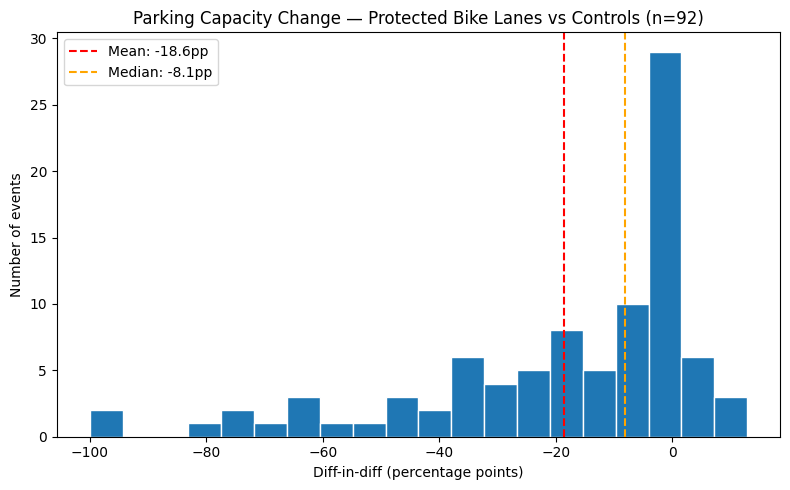

In [36]:
import matplotlib.pyplot as plt

high_conf_bike = event_summary_typed_clean[
    (~event_summary_typed_clean['low_confidence']) &
    (event_summary_typed_clean['InterventionType'] == 'ProtectedBikeLane')
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(high_conf_bike['diff_in_diff'], bins=20, edgecolor='white')
ax.axvline(high_conf_bike['diff_in_diff'].mean(), color='red', linestyle='--', label=f"Mean: {high_conf_bike['diff_in_diff'].mean():.1f}pp")
ax.axvline(high_conf_bike['diff_in_diff'].median(), color='orange', linestyle='--', label=f"Median: {high_conf_bike['diff_in_diff'].median():.1f}pp")
ax.set_xlabel("Diff-in-diff (percentage points)")
ax.set_ylabel("Number of events")
ax.set_title(f"Parking Capacity Change — Protected Bike Lanes vs Controls (n={len(high_conf_bike)})")
ax.legend()
plt.tight_layout()
plt.show()

#### Comparing Intervention Types Side-by-Side

A boxplot puts Pedestrianisation and Protected Bike Lane results on the same axis, making the
difference in both typical effect size and variability immediately visible.

/tmp/ipykernel_41441/3955624262.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_type, labels=['Pedestrianisation', 'Protected Bike Lane'], showmeans=True)


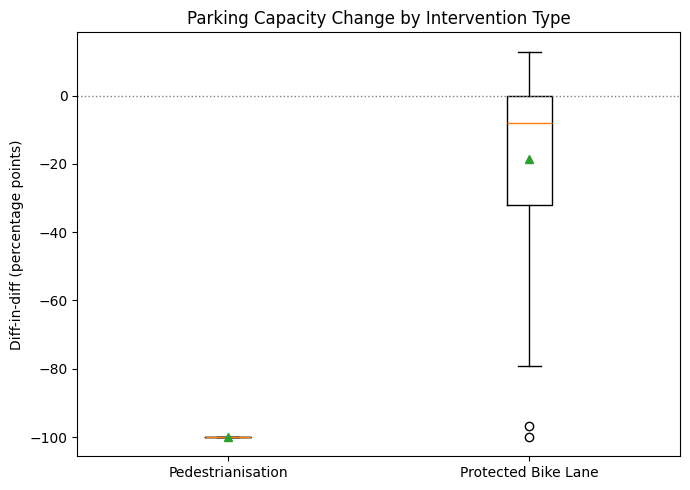

In [37]:
import matplotlib.pyplot as plt

high_conf = event_summary_typed_clean[~event_summary_typed_clean['low_confidence']]

fig, ax = plt.subplots(figsize=(7, 5))
data_by_type = [high_conf[high_conf['InterventionType']==t]['diff_in_diff'].dropna() for t in ['Pedestrianisation', 'ProtectedBikeLane']]
ax.boxplot(data_by_type, labels=['Pedestrianisation', 'Protected Bike Lane'], showmeans=True)
ax.axhline(0, color='grey', linestyle=':', linewidth=1)
ax.set_ylabel("Diff-in-diff (percentage points)")
ax.set_title("Parking Capacity Change by Intervention Type")
plt.tight_layout()
plt.show()

#### Before vs After Capacity, Every Event

Each point is one event: x-axis is capacity before, y-axis is capacity after. Points below the diagonal line lost capacity; points above gained it; points on the line saw no change.

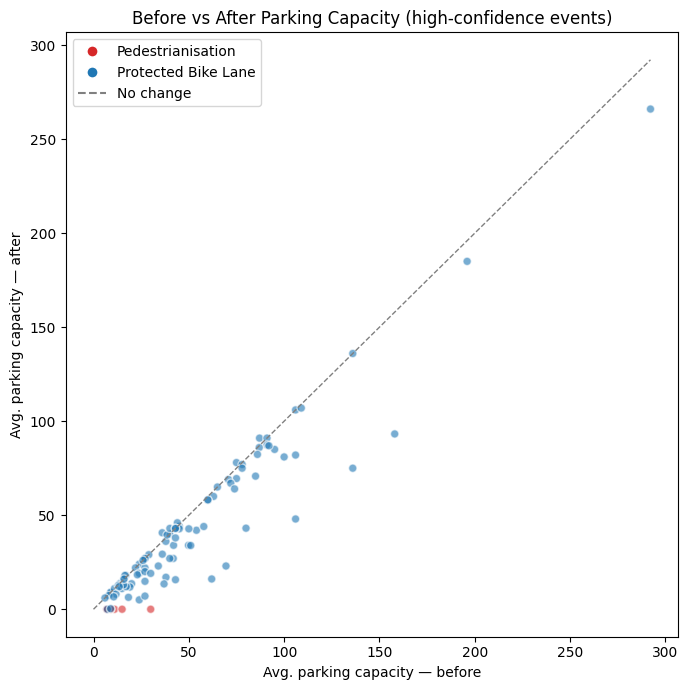

In [38]:
fig, ax = plt.subplots(figsize=(7, 7))
colors = high_conf['InterventionType'].map({'Pedestrianisation': 'tab:red', 'ProtectedBikeLane': 'tab:blue'})
ax.scatter(high_conf['avg_cap_before'], high_conf['avg_cap_after'], c=colors, alpha=0.6, edgecolor='white')

max_val = max(high_conf['avg_cap_before'].max(), high_conf['avg_cap_after'].max())
ax.plot([0, max_val], [0, max_val], color='grey', linestyle='--', linewidth=1, label='No change')

ax.set_xlabel("Avg. parking capacity — before")
ax.set_ylabel("Avg. parking capacity — after")
ax.set_title("Before vs After Parking Capacity (high-confidence events)")
handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=c, label=l, markersize=8)
           for c, l in [('tab:red','Pedestrianisation'), ('tab:blue','Protected Bike Lane')]]
ax.legend(handles=handles + [plt.Line2D([0],[0], color='grey', linestyle='--', label='No change')])
plt.tight_layout()
plt.show()

#### Top 10 Streets by Parking Capacity Loss

Naming specific streets makes the finding concrete and checkable, rather than an abstract
statistic - useful for a policy audience who may know these locations directly.

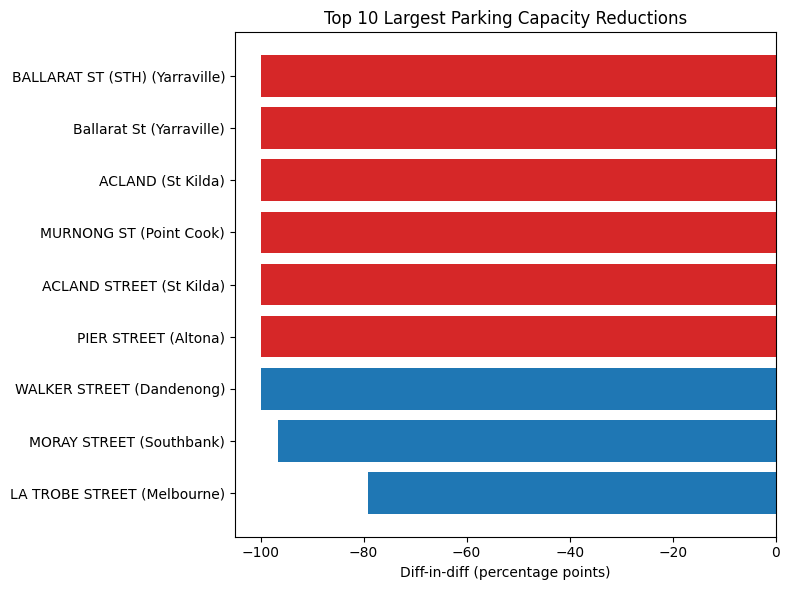

In [39]:
top10 = high_conf.nsmallest(10, 'diff_in_diff')[['street_name', 'suburb', 'InterventionType', 'diff_in_diff']]
top10_labels = top10['street_name'] + " (" + top10['suburb'] + ")"

fig, ax = plt.subplots(figsize=(8, 6))
bar_colors = top10['InterventionType'].map({'Pedestrianisation': 'tab:red', 'ProtectedBikeLane': 'tab:blue'})
ax.barh(top10_labels, top10['diff_in_diff'], color=bar_colors)
ax.set_xlabel("Diff-in-diff (percentage points)")
ax.set_title("Top 10 Largest Parking Capacity Reductions")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

#### Analysis Coverage and Confidence Breakdown

This chart shows how the study population was narrowed down at each stage, and why -
important for the PO to see the full funnel, not just the final headline number.

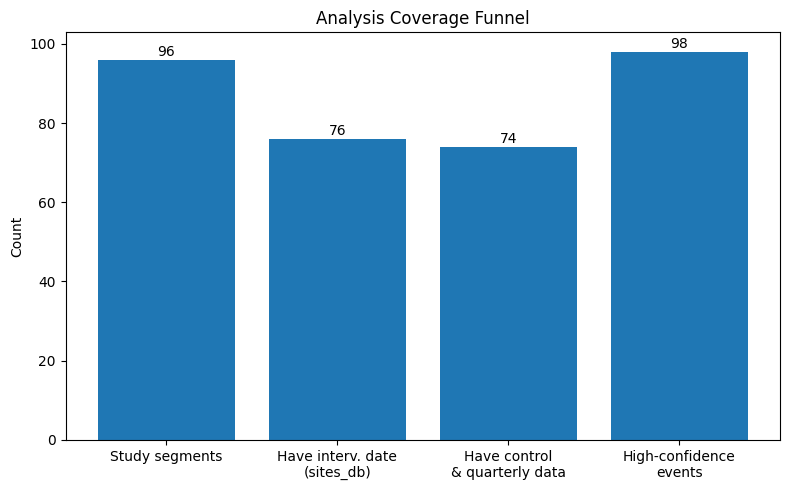

In [40]:
funnel_labels = ['Study segments', 'Have interv. date\n(sites_db)', 'Have control\n& quarterly data', 'High-confidence\nevents']
funnel_values = [96, 76, 74, high_conf['event_id'].nunique()]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(funnel_labels, funnel_values, color='tab:blue')
for bar, val in zip(bars, funnel_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val), ha='center')
ax.set_ylabel("Count")
ax.set_title("Analysis Coverage Funnel")
plt.tight_layout()
plt.show()

#### Final Headline Summary

In [41]:
summary_final = event_summary_typed_clean[~event_summary_typed_clean['low_confidence']].groupby('InterventionType')['diff_in_diff'].agg(n='count', mean='mean', median='median', std='std').round(1)
print(summary_final)
print()
for itype, row in summary_final.iterrows():
    print(f"{itype}: average change of {row['mean']}pp (median {row['median']}pp) relative to control streets, across {int(row['n'])} high-confidence events.")

                    n   mean  median   std
InterventionType                          
Pedestrianisation   6 -100.0  -100.0   0.0
ProtectedBikeLane  92  -18.6    -8.1  24.7

Pedestrianisation: average change of -100.0pp (median -100.0pp) relative to control streets, across 6 high-confidence events.
ProtectedBikeLane: average change of -18.6pp (median -8.1pp) relative to control streets, across 92 high-confidence events.


#### Saving Final Output

Saving the final event-level result set (with confidence flagging) so the rest of the team can build on it directly — example, for dashboarding or the final report, without re-running this entire notebook.

In [42]:
final_output = event_summary_typed_clean.copy()
OUTPUT_PATH = "/content/drive/MyDrive/usia_teamB_diff_in_diff_results.csv"
final_output.to_csv(OUTPUT_PATH, index=False)
print(f"Saved {len(final_output)} rows to {OUTPUT_PATH}")

Saved 157 rows to /content/drive/MyDrive/usia_teamB_diff_in_diff_results.csv


#### Methodology & Limitations Summary

**Method:** Using PO-supplied `sites_db.csv` (ID-keyed, replacing the earlier unreliable
name-based pop-up lane join) and `street_segment_qtr_attributes.csv` (quarterly parking
capacity, 1999–2025), we identified 76 treatment segments with confirmed intervention dates, producing 202 individual disruption events. Each event's before/after window is bounded by its neighbouring events on the same segment to avoid double-counting overlapping periods. Each event is compared against matched control streets (suburb, falling back to LGA) over the same calendar window, producing a percentage-point diff-in-diff measure.

**Key limitations:**
- 1 segment (Wodonga) excluded — no comparable control street available.
- 2 segments (La Trobe St, Southbank Blvd) excluded — no quarterly data available.
- Events with a before/after window under 4 quarters, a baseline capacity under 5 spots, or
  belonging to a segment's 4th+ recorded event are flagged as low-confidence and excluded from
  the headline figure (59 of 157 events), since these are more likely to reflect thin samples,
  small-denominator distortion, or contamination from an adjacent disruption event.
- Diff-in-diff is undefined (excluded, not zeroed) where a baseline capacity is exactly 0.
- Analysis is limited to on-street parking *capacity* (a design/infrastructure field); it does
  not yet measure actual parking *occupancy/utilisation*, which would require the imagery or
  sensor-based strands of Team B's work.

#### Interpretive Synopsis

Pedestrianisation interventions are associated with a complete, consistent loss of on-street
parking capacity (-100%, n=6) — an expected and mechanical result, since pedestrianisation
removes vehicle access entirely.

Protected bike lanes show a more moderate, more variable effect: an average reduction of
around 18.6 percentage points relative to comparable control streets, though the median
(-8.1pp) suggests the typical impact is smaller than the mean implies — most sites saw a modest
reduction, with a smaller subset of sites (particularly fully separated/protected lane designs)
losing 60-100% of capacity. This is consistent with some installations retaining partial
on-street parking (e.g. floating parking lanes) while others remove it entirely.

These findings are indicative rather than definitive, in line with the PO's stated expectations
for this Sprint — they establish a working before/after methodology on real data, with the main
avenues for refinement being: resolving the closely-spaced multi-event streets currently
excluded as low-confidence, and extending the analysis from parking capacity to actual
utilisation once sensor/imagery data is incorporated.